# SAFOD June 2026 AWD: clean end-to-end analysis

This notebook is the single entry point for the AWD-only workflow. It excludes the four conventional shots, treats the AWD as a fixed source approximately 15 m from the Nano wellhead, and uses fiber coordinate rather than claiming calibrated depth. Phase names are withheld until supported by null tests and waveform inspection.

## Configuration
Set `REBUILD_RAW=True` only when the 2.7 GB canonical paired stack must be recreated. The rebuild takes about 50 minutes and requires roughly 64 GB RAM, so it should normally be run through the supplied Sherlock job rather than inside Jupyter.

In [1]:
from pathlib import Path
import subprocess, sys
import numpy as np
import pandas as pd
from IPython.display import Image, display, Markdown

HERE = Path.cwd()
if HERE.name != 'awd_clean':
    HERE = HERE / 'awd_clean'
assert HERE.exists(), HERE
REBUILD_RAW = False
RUN_DERIVED_ANALYSES = False  # True reruns scans, repeatability, and null tests locally
HERE

PosixPath('/home/groups/ettore88/nberrios/safod_das_git/notebooks/awd_clean')

## 1. Reconstruct the authoritative GPS drop manifest

In [2]:
subprocess.run([sys.executable, str(HERE/'build_manifest.py')], check=True)
manifest = pd.read_csv(HERE/'awd_manifest.csv')
display(manifest.head())
display(manifest.groupby('burst_id').agg(drops=('drop_id','size'), nano=('nano_available','sum'), deep=('deep_available','sum'), paired=('paired_available','sum')))

Nano files: 589; Deep files: 2835
GPS drops in Nano coverage: 989
Qualifying AWD bursts: 49; drops: 988
Drops per burst: min=19, max=23
Wrote /home/groups/ettore88/nberrios/safod_das_git/notebooks/awd_clean/awd_manifest.csv


,burst_id,drop_id,utc_time,seconds_from_burst_start,gps_max_cc,gps_diff_prev_s,nano_available,nano_file,nano_offset_s,deep_available,deep_file,deep_offset_s,paired_available
0,0,0,2026-06-16T23:47:09.409500+00:00,0.0000,0.9282,0.0,1,timeseriesScaler_2026-06-16_23.43.28_UTC_00029...,221.4095,1,SAFOD-Deep-10mGL-1000HzFs-2mChDualPulse_2026-0...,21.4095,1
1,0,1,2026-06-16T23:47:23.100000+00:00,13.6905,0.9969,13.7,1,timeseriesScaler_2026-06-16_23.43.28_UTC_00029...,235.1000,1,SAFOD-Deep-10mGL-1000HzFs-2mChDualPulse_2026-0...,35.1000,1
2,0,2,2026-06-16T23:47:32.557000+00:00,23.1475,0.9196,9.5,1,timeseriesScaler_2026-06-16_23.43.28_UTC_00029...,244.5570,1,SAFOD-Deep-10mGL-1000HzFs-2mChDualPulse_2026-0...,44.5570,1
3,0,3,2026-06-16T23:47:41.957000+00:00,32.5475,0.9983,9.4,1,timeseriesScaler_2026-06-16_23.43.28_UTC_00029...,253.9570,1,SAFOD-Deep-10mGL-1000HzFs-2mChDualPulse_2026-0...,53.9570,1
4,0,4,2026-06-16T23:47:51.841500+00:00,42.4320,0.9988,9.9,1,timeseriesScaler_2026-06-16_23.43.28_UTC_00029...,263.8415,1,SAFOD-Deep-10mGL-1000HzFs-2mChDualPulse_2026-0...,3.8415,1


,drops,nano,deep,paired
burst_id,,,,
0,20,20,20,20
1,20,20,20,20
2,20,20,20,20
3,20,20,20,20
4,21,21,21,21
5,20,20,20,20
6,19,19,19,19
7,20,20,20,20
8,21,21,21,21


## 2. Canonical raw-data rebuild
This step preserves all 49 GPS-defined bursts and extracts complete $-0.5$ to $+3.0$ s Nano/Deep windows. It is skipped by default because the completed product already exists.

In [3]:
canonical = HERE/'canonical_epoch_stacks_paired_deep_all.npz'
if REBUILD_RAW:
    subprocess.run([sys.executable, str(HERE/'run_canonical_rebuild.py')], check=True)
assert canonical.exists(), 'Canonical product missing; submit rebuild_stacks.sbatch'
with np.load(canonical) as d:
    print('Nano:', d['nano_stacks'].shape, 'Deep:', d['deep_stacks'].shape)
    print('Complete common windows:', int(d['n_common'].sum()))
    print('Bursts with paired data:', int((d['n_common'] > 0).sum()), 'of', len(d['n_common']))

Nano: (49, 732, 3500) Deep: (49, 3200, 3500)
Complete common windows: 859
Bursts with paired data: 46 of 49


## 3. Phase-neutral multiband scan, repeatability, and null tests

In [4]:
if RUN_DERIVED_ANALYSES:
    for script in ('analyze_modes.py', 'measure_repeatability.py', 'null_tests_and_inspection.py'):
        print('Running', script)
        subprocess.run([sys.executable, str(HERE/script)], check=True)
else:
    print('Using completed derived products. Set RUN_DERIVED_ANALYSES=True to recreate them.')

Using completed derived products. Set RUN_DERIVED_ANALYSES=True to recreate them.


## 4. Inspect coherent-moveout surfaces

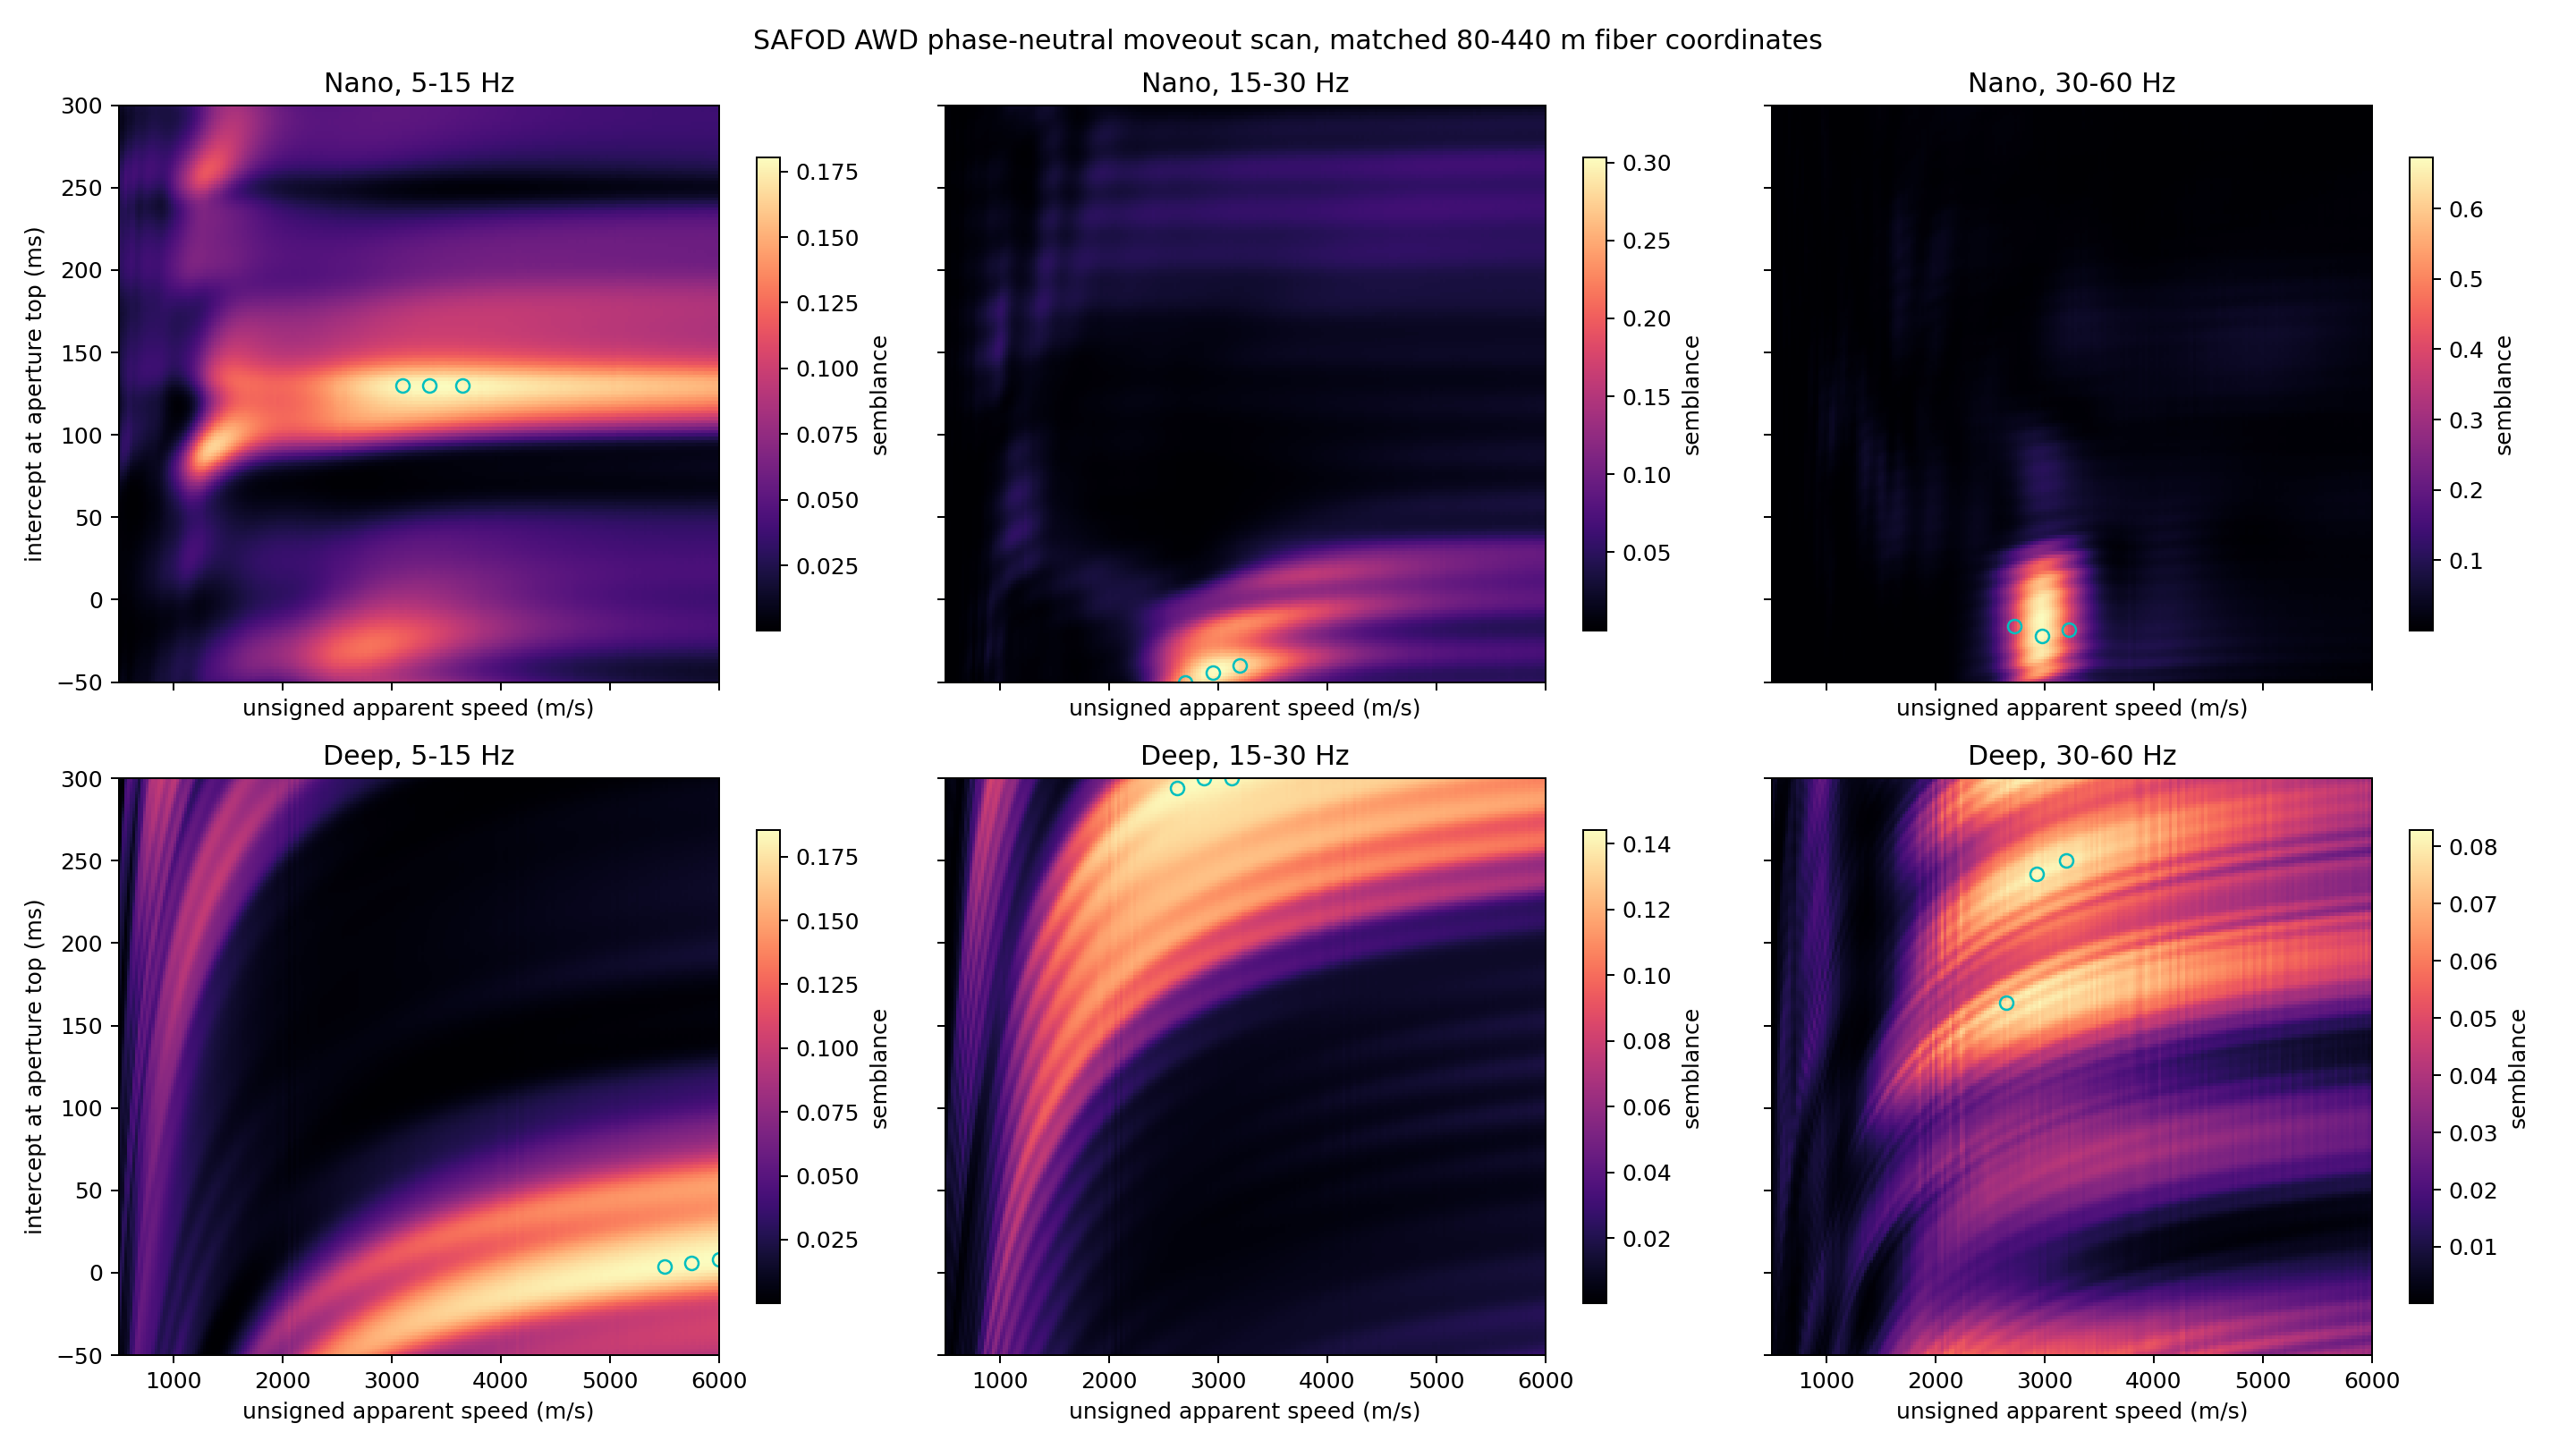

In [5]:
display(Image(filename=str(HERE/'mode_scan.png')))


## 5. Inspect burst-to-burst repeatability

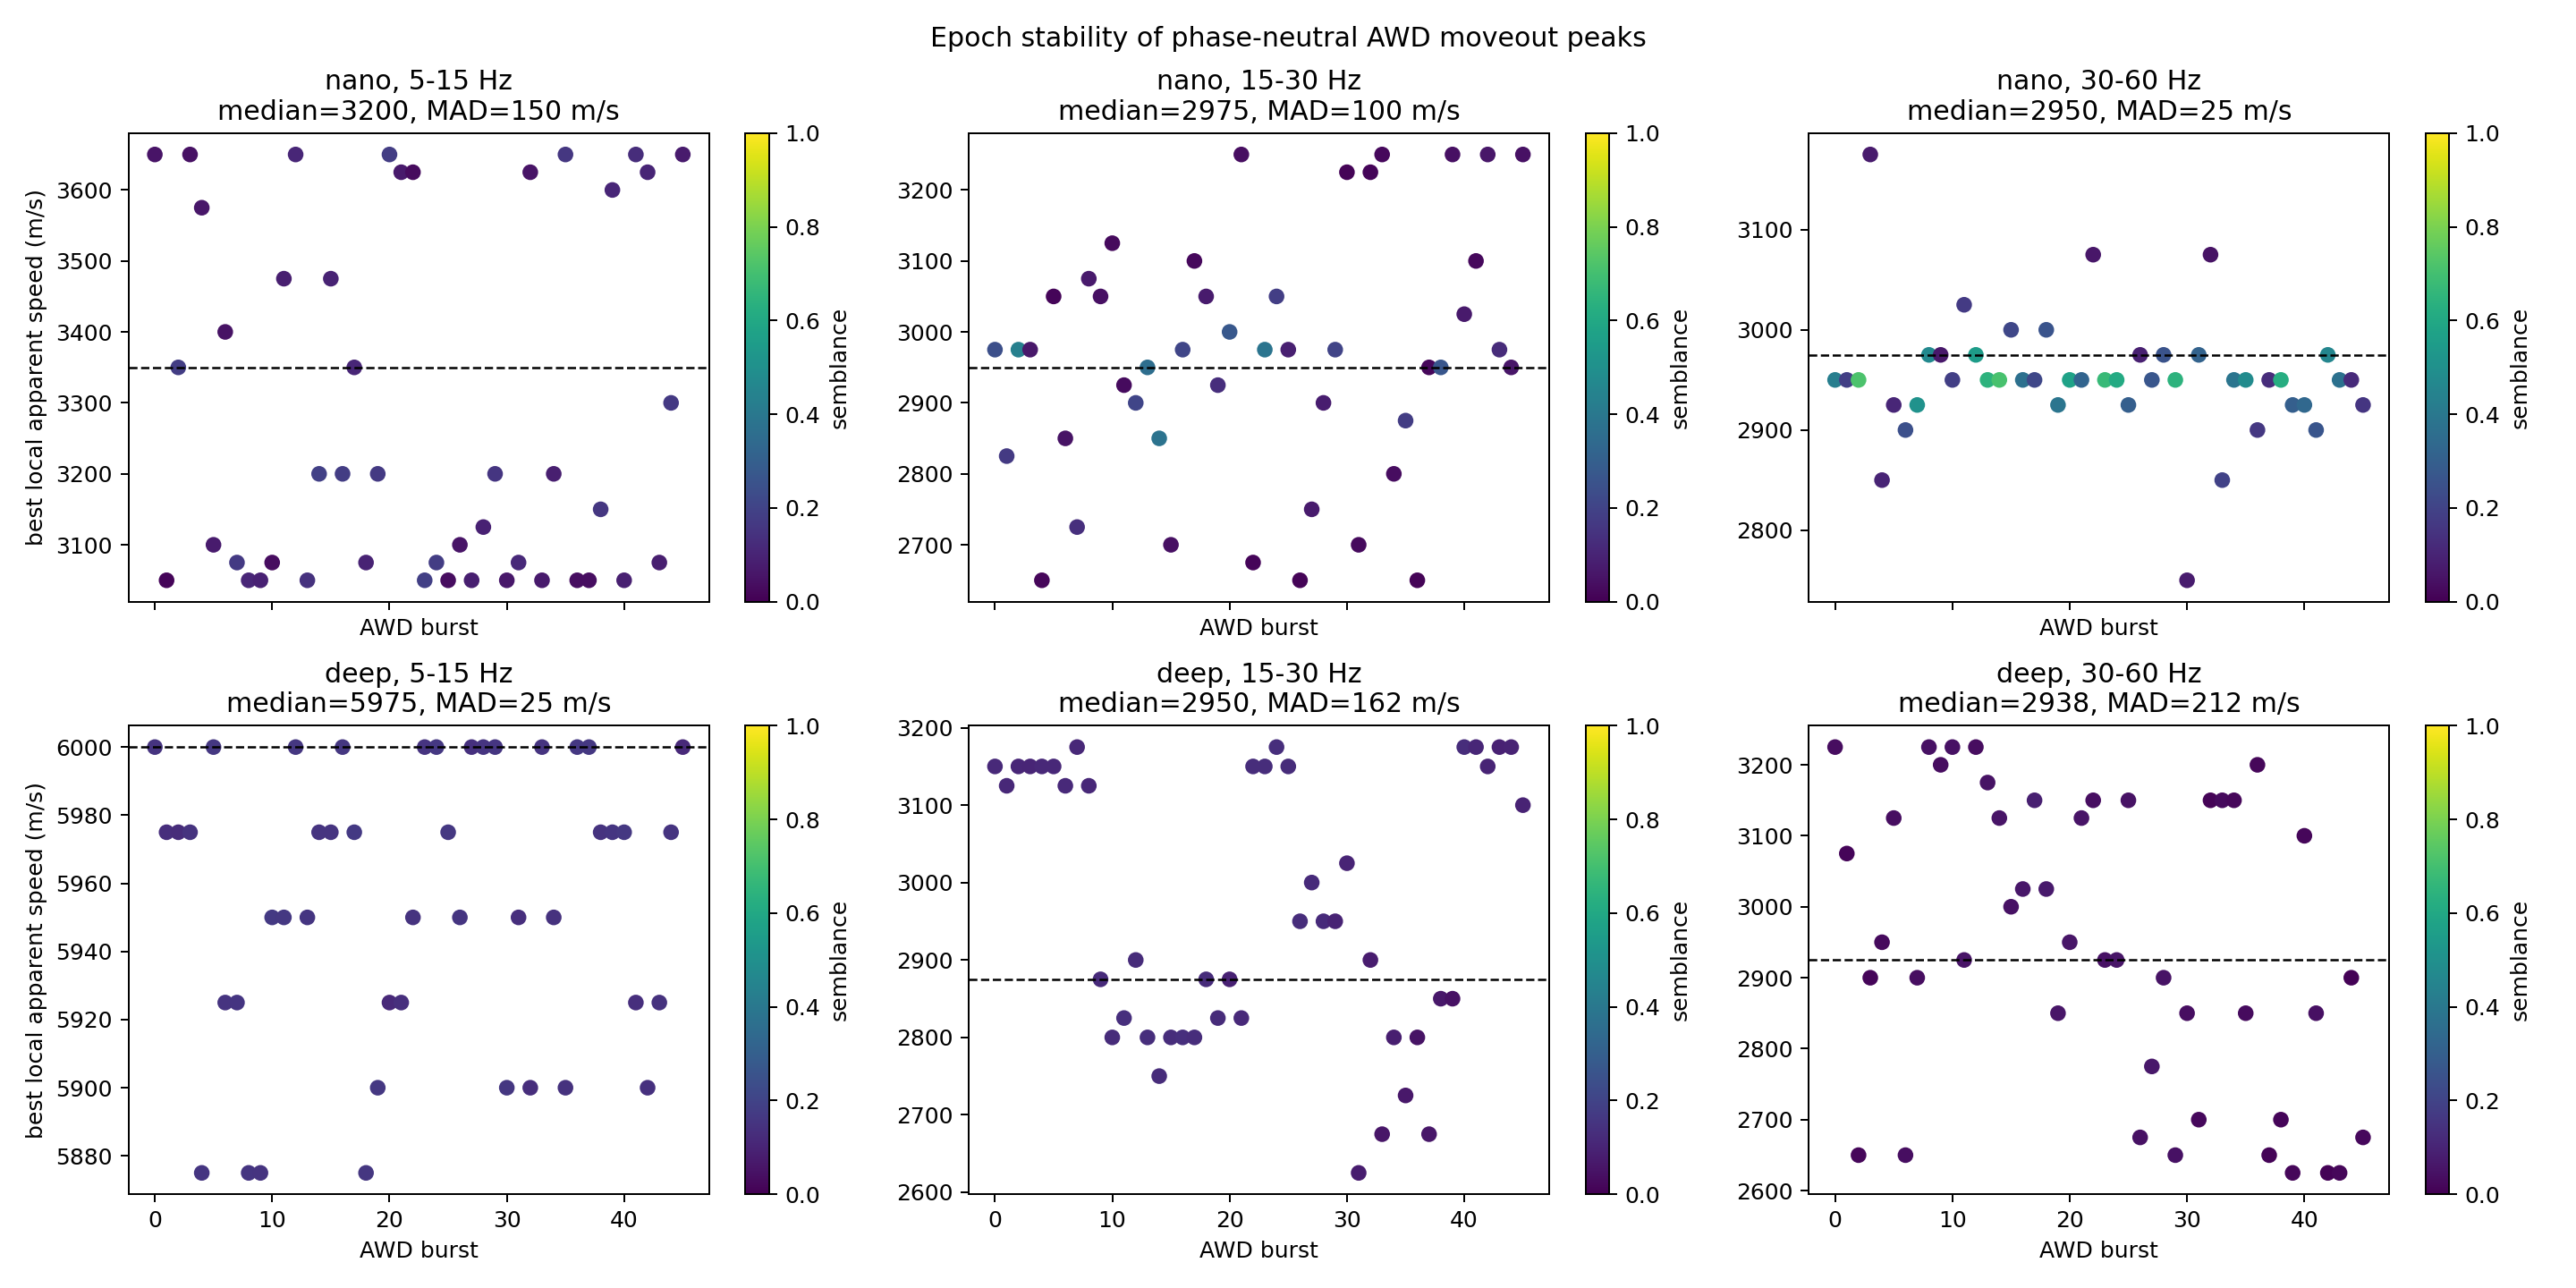

n   mean_speed  median_speed  mean_semblance  \
fiber band_low_hz band_high_hz                                                  
deep  5.0         15.0          46  5954.891304        5975.0        0.149179   
      15.0        30.0          46  2965.217391        2950.0        0.105649   
      30.0        60.0          46  2948.913043        2937.5        0.036104   
nano  5.0         15.0          46  3284.782609        3200.0        0.100250   
      15.0        30.0          46  2962.500000        2975.0        0.109392   
      30.0        60.0          46  2952.173913        2950.0        0.321881   

                                strong  
fiber band_low_hz band_high_hz          
deep  5.0         15.0               0  
      15.0        30.0               0  
      30.0        60.0               0  
nano  5.0         15.0               0  
      15.0        30.0               9  
      30.0        60.0              30

In [6]:
repeat = pd.read_csv(HERE/'mode_repeatability.csv')
display(Image(filename=str(HERE/'mode_repeatability.png')))
display(repeat.groupby(['fiber','band_low_hz','band_high_hz']).agg(n=('epoch','size'), mean_speed=('epoch_speed_mps','mean'), median_speed=('epoch_speed_mps','median'), mean_semblance=('epoch_semblance','mean'), strong=('epoch_semblance', lambda x: int((x > 0.2).sum()))))

## 6. Null tests and unnormalized record-section inspection
The depth-permutation control destroys spatial ordering while preserving each channel waveform. The pre-source control searches for comparable coherence before the GPS drop. The observed and null searches use the same local speed/intercept grid, accounting for local look-elsewhere selection.

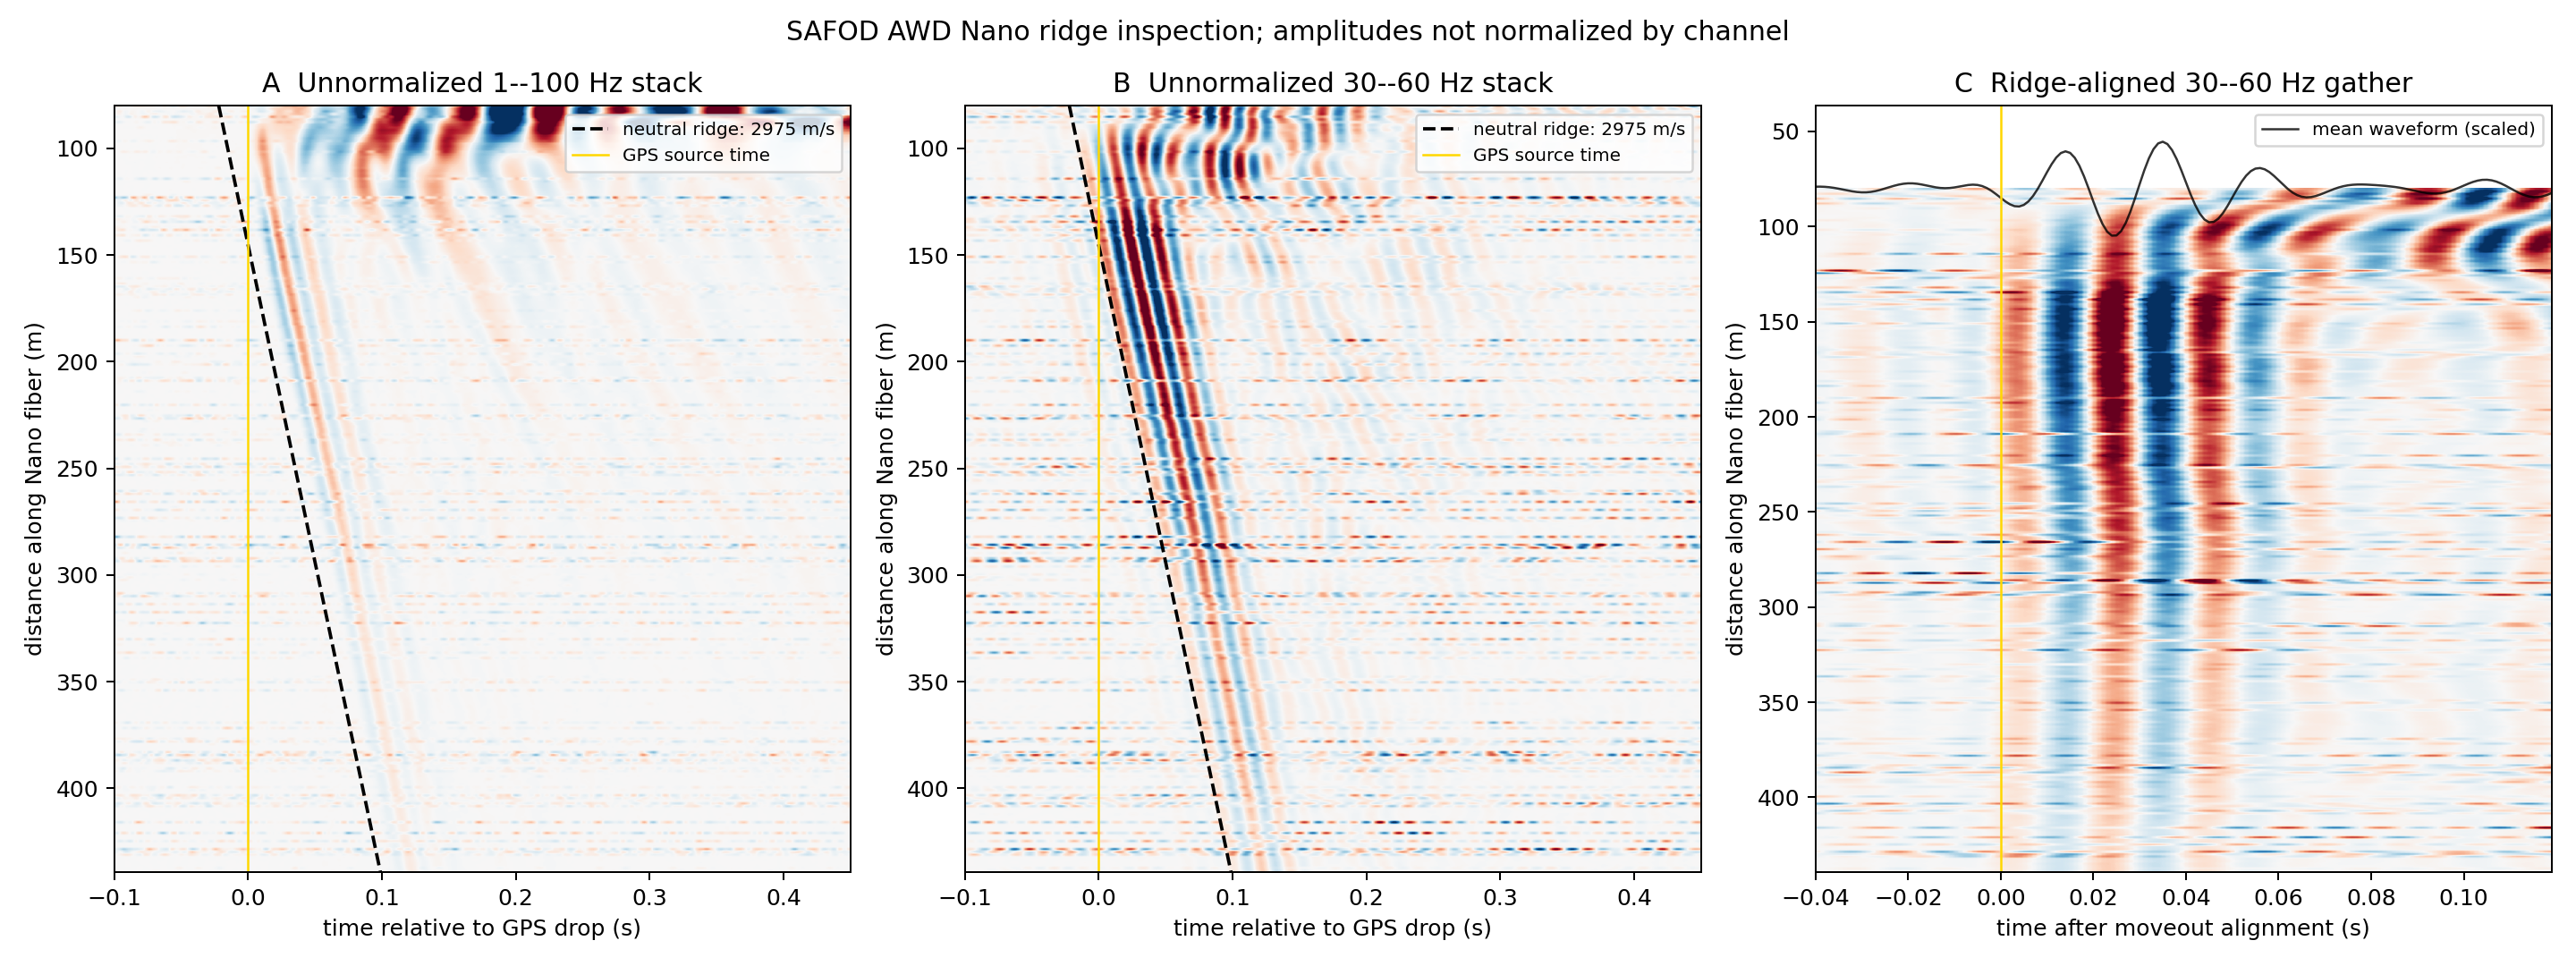

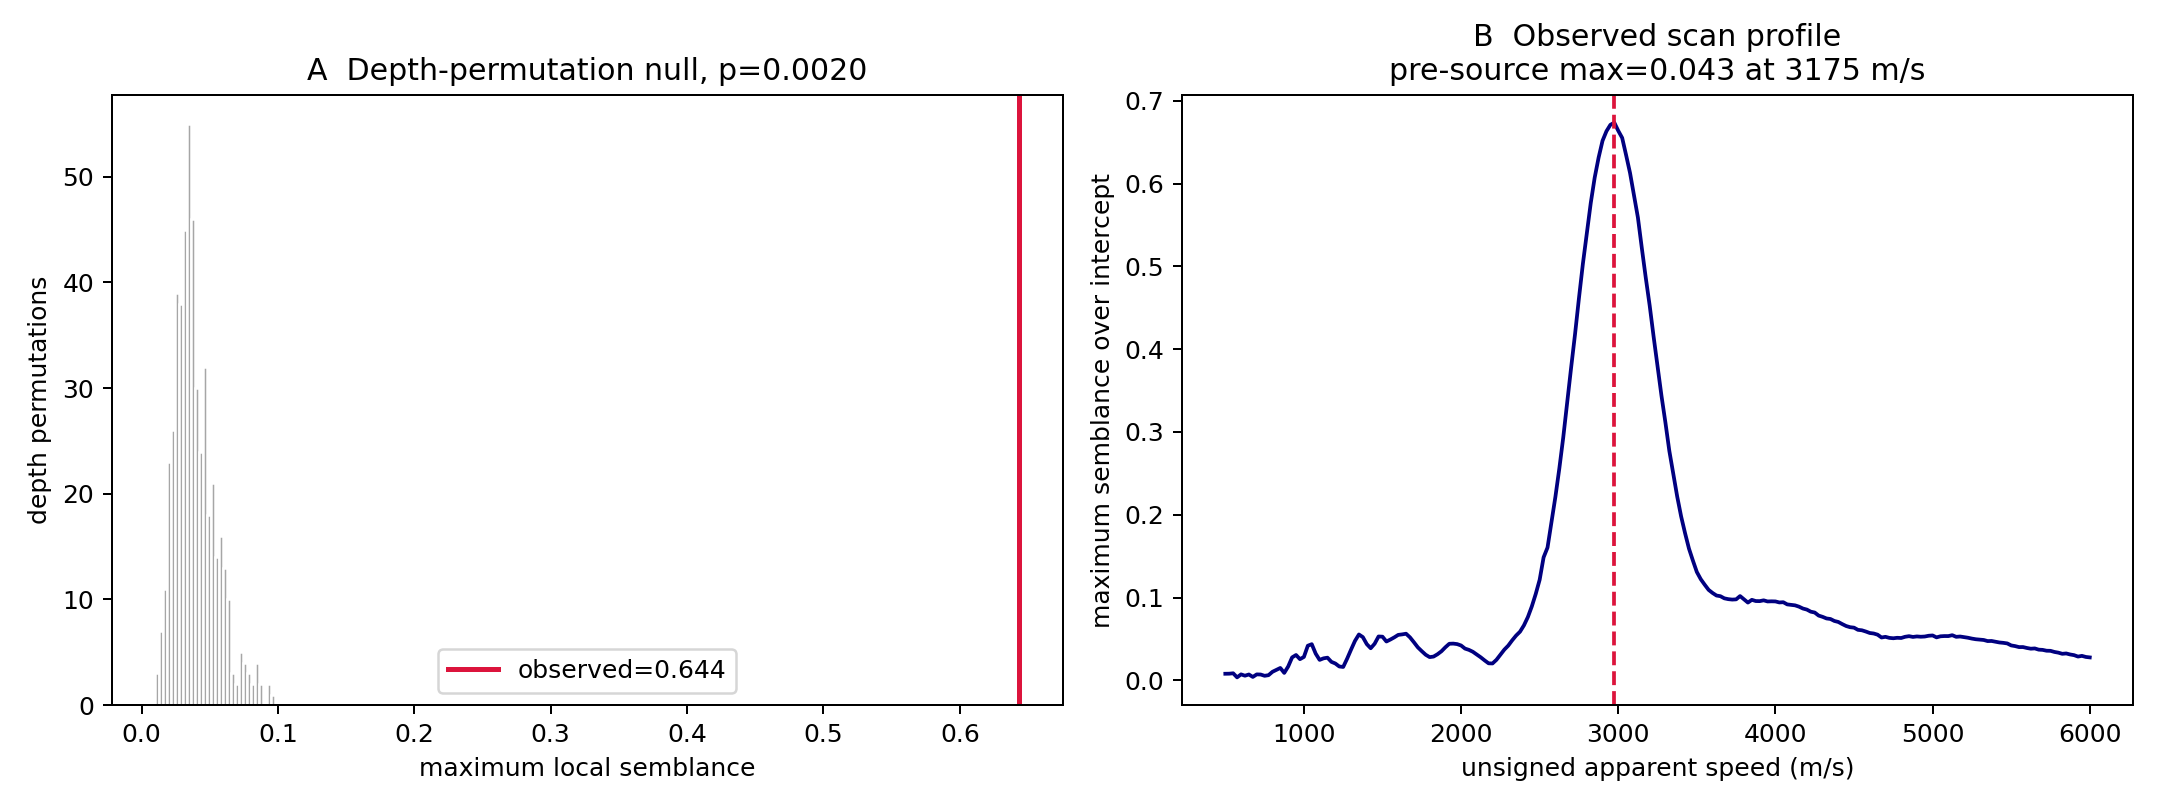

```text
SAFOD AWD phase-neutral null tests
band: 30-60 Hz
Nano fiber-coordinate aperture: 80-440 m
observed coarse local-max semblance: 0.643689
observed speed/intercept: 2975.0 m/s, -22.0 ms
depth permutations: 499; seed: 20260801
permutation p-value (local look-elsewhere corrected): 0.002000
largest pre-source control: 0.042945
pre-source speed/intercept: 3175.0 m/s, -358.0 ms

```

In [7]:
for name in ('record_section_inspection.png', 'null_tests.png'):
    path = HERE/name
    if path.exists(): display(Image(filename=str(path)))
    else: print(path.name, 'not available yet')
report = HERE/'null_test_report.txt'
if report.exists(): display(Markdown('```text\n' + report.read_text() + '\n```'))

## Interpretation rule
The approximately 3 km/s Nano ridge is called a **phase-neutral coherent mode** until it (1) exceeds the permutation and pre-source controls, (2) is visibly an early coherent arrival in the unnormalized section, and (3) has geometry and frequency behavior consistent with a direct body wave. A statistically significant ridge alone is not sufficient to call it P.